In [ ]:
import pandas as pd
import yaml
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.mining.clustering import calculate_clustering_metrics, perform_kmeans, get_cluster_profiles
from src.visualization.plots import plot_elbow_method

# 1. Đọc Config và Load dữ liệu từ file CSV đã lưu
with open('../configs/params.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Đọc file đã xử lý sạch (Lưu ý: dùng path từ config)
df_final = pd.read_csv(f"../{config['processed_data_path']}")
features = config['clustering']['features']
X = df_final[features]


In [ ]:
# 2. Tìm số cụm phù hợp (Ví dụ thử từ 2 đến 8 cụm)
k_range = range(2, 9)
inertia, silhouette = calculate_clustering_metrics(X, k_range)



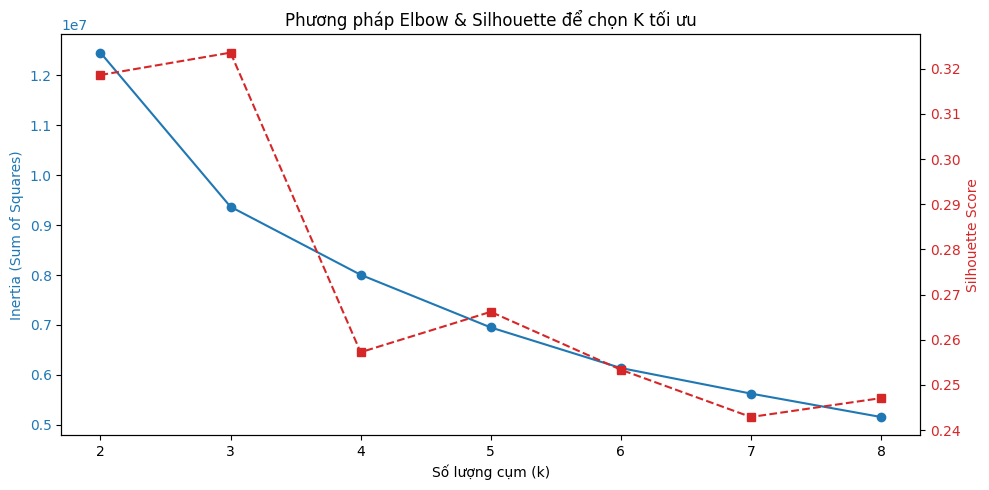

In [ ]:
# 3. Vẽ biểu đồ để chọn K
plot_elbow_method(k_range, inertia, silhouette)


In [ ]:

best_k = 3 

# 4. Chạy K-Means với k tối ưu
kmeans_model, clusters = perform_kmeans(X, features, n_clusters=best_k)
df_final['Cluster'] = clusters


In [ ]:
# 5. Lập Hồ sơ cụm
profile = get_cluster_profiles(df_final, features, 'Cluster')
display(profile)

,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars),Count
Cluster,,,,,
0,7.386691,0.781305,18.558023,1009.709763,19174
1,24.444028,0.524570,11.772948,1014.434016,22738
2,1.604899,0.838468,8.601018,1025.013964,24513
3,13.792495,0.779986,6.938760,1016.447686,30028
